# V55: Comparison - Graph (MIS) vs No-Graph (Greedy) Selection

## Tujuan Eksperimen

Notebook ini membandingkan **3 metode seleksi aset** untuk membuktikan kontribusi masing-masing komponen:

### Metode yang Dibandingkan:

1. **V54 Alphabetical + Graph (MIS)**
   - Urutan: A-Z (Bias)
   - Seleksi: Maximum Independent Set (Graph Theory)
   - Baseline untuk perbandingan

2. **V55 Smart Momentum + Graph (MIS)**
   - Urutan: Momentum Tertinggi → Terendah
   - Seleksi: Maximum Independent Set (Graph Theory)
   - Menunjukkan nilai Smart Sorting

3. **V55 Smart Momentum + No-Graph (Greedy)**
   - Urutan: Momentum Tertinggi → Terendah
   - Seleksi: Greedy (tanpa Graph Theory)
   - Menunjukkan apakah Graph Theory diperlukan

### Hipotesis:
- **H1:** Smart Momentum > Alphabetical (membuktikan nilai sorting)
- **H2:** Graph (MIS) ≈ No-Graph (Greedy) jika urutan sudah optimal (membuktikan Graph optional)

### Parameter:
- AI: XGBoost (threshold optimized)
- Trend Override: SMA 50
- Transaction Fee: 0.25%
- Rebalancing: 20 hari
- Correlation Threshold: 0.4
- Random Seed: 42

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")

Data: 712 rows, 30 assets
Period: 2023-01-02 00:00:00 to 2025-12-30 00:00:00


In [3]:
# AI Training
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
                                              for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [4]:
# Asset Selection Methods

def get_assets_alphabetical_graph(returns_window, corr_threshold=0.4):
    """V54: Alphabetical + Graph (MIS)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = sorted(returns_window.columns)  # A-Z
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_momentum_graph(returns_window, corr_threshold=0.4):
    """V55: Smart Momentum + Graph (MIS)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Momentum
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_momentum_greedy(returns_window, corr_threshold=0.4):
    """V55: Smart Momentum + No-Graph (Greedy)"""
    corr_mat = returns_window.corr()
    
    # Sort by Momentum
    momentum = returns_window.mean()
    sorted_assets = list(momentum.sort_values(ascending=False).index)
    
    selected = []
    for asset in sorted_assets:
        # Check if uncorrelated with already selected assets
        is_uncorrelated = True
        for selected_asset in selected:
            if abs(corr_mat.loc[asset, selected_asset]) > corr_threshold:
                is_uncorrelated = False
                break
        
        if is_uncorrelated:
            selected.append(asset)
    
    return selected

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("Asset selection methods defined!")

Asset selection methods defined!


In [5]:
# Simulation Function

def run_simulation(test_dates, returns, ai_probs, threshold, market_idx, 
                   selection_func,  # Function to select assets
                   override_ma=None, 
                   fee=0.0025, 
                   g_lookback=60, 
                   rebal_period=20, 
                   turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # AI Signal
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        # Trend Override
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True
            except KeyError:
                pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                
                # USE PROVIDED SELECTION FUNCTION
                selected = selection_func(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # Execution
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Simulation function ready!")

Simulation function ready!


In [6]:
# Run All Strategies

print("Running simulations...\n")

# 1. V54: Alphabetical + Graph (MIS)
print("1. V54: Alphabetical + Graph (MIS)...")
v54_alpha_graph = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                                 get_assets_alphabetical_graph, override_ma=50)

# 2. V55: Smart Momentum + Graph (MIS)
print("2. V55: Smart Momentum + Graph (MIS)...")
v55_momentum_graph = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                                    get_assets_momentum_graph, override_ma=50)

# 3. V55: Smart Momentum + No-Graph (Greedy)
print("3. V55: Smart Momentum + No-Graph (Greedy)...")
v55_momentum_greedy = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                                     get_assets_momentum_greedy, override_ma=50)

# 4. Index Benchmark
lq45_idx = market_index.loc[X_test.index] / market_index.loc[X_test.index[0]] * 100

print("\n=== RESULTS ===")
print(f"V54 (Alphabetical + Graph):    {v54_alpha_graph.iloc[-1].values[0]:.2f}")
print(f"V55 (Momentum + Graph):         {v55_momentum_graph.iloc[-1].values[0]:.2f}")
print(f"V55 (Momentum + Greedy):        {v55_momentum_greedy.iloc[-1].values[0]:.2f}")
print(f"LQ45 Index:                     {lq45_idx.iloc[-1]:.2f}")

print("\n=== ANALYSIS ===")
smart_vs_alpha = ((v55_momentum_graph.iloc[-1].values[0] / v54_alpha_graph.iloc[-1].values[0]) - 1) * 100
graph_vs_greedy = ((v55_momentum_graph.iloc[-1].values[0] / v55_momentum_greedy.iloc[-1].values[0]) - 1) * 100

print(f"Smart Momentum vs Alphabetical: {smart_vs_alpha:+.2f}% (nilai Smart Sorting)")
print(f"Graph (MIS) vs Greedy:          {graph_vs_greedy:+.2f}% (nilai Graph Theory)")

Running simulations...

1. V54: Alphabetical + Graph (MIS)...
2. V55: Smart Momentum + Graph (MIS)...
3. V55: Smart Momentum + No-Graph (Greedy)...

=== RESULTS ===
V54 (Alphabetical + Graph):    132.24
V55 (Momentum + Graph):         211.27
V55 (Momentum + Greedy):        205.60
LQ45 Index:                     119.44

=== ANALYSIS ===
Smart Momentum vs Alphabetical: +59.76% (nilai Smart Sorting)
Graph (MIS) vs Greedy:          +2.76% (nilai Graph Theory)


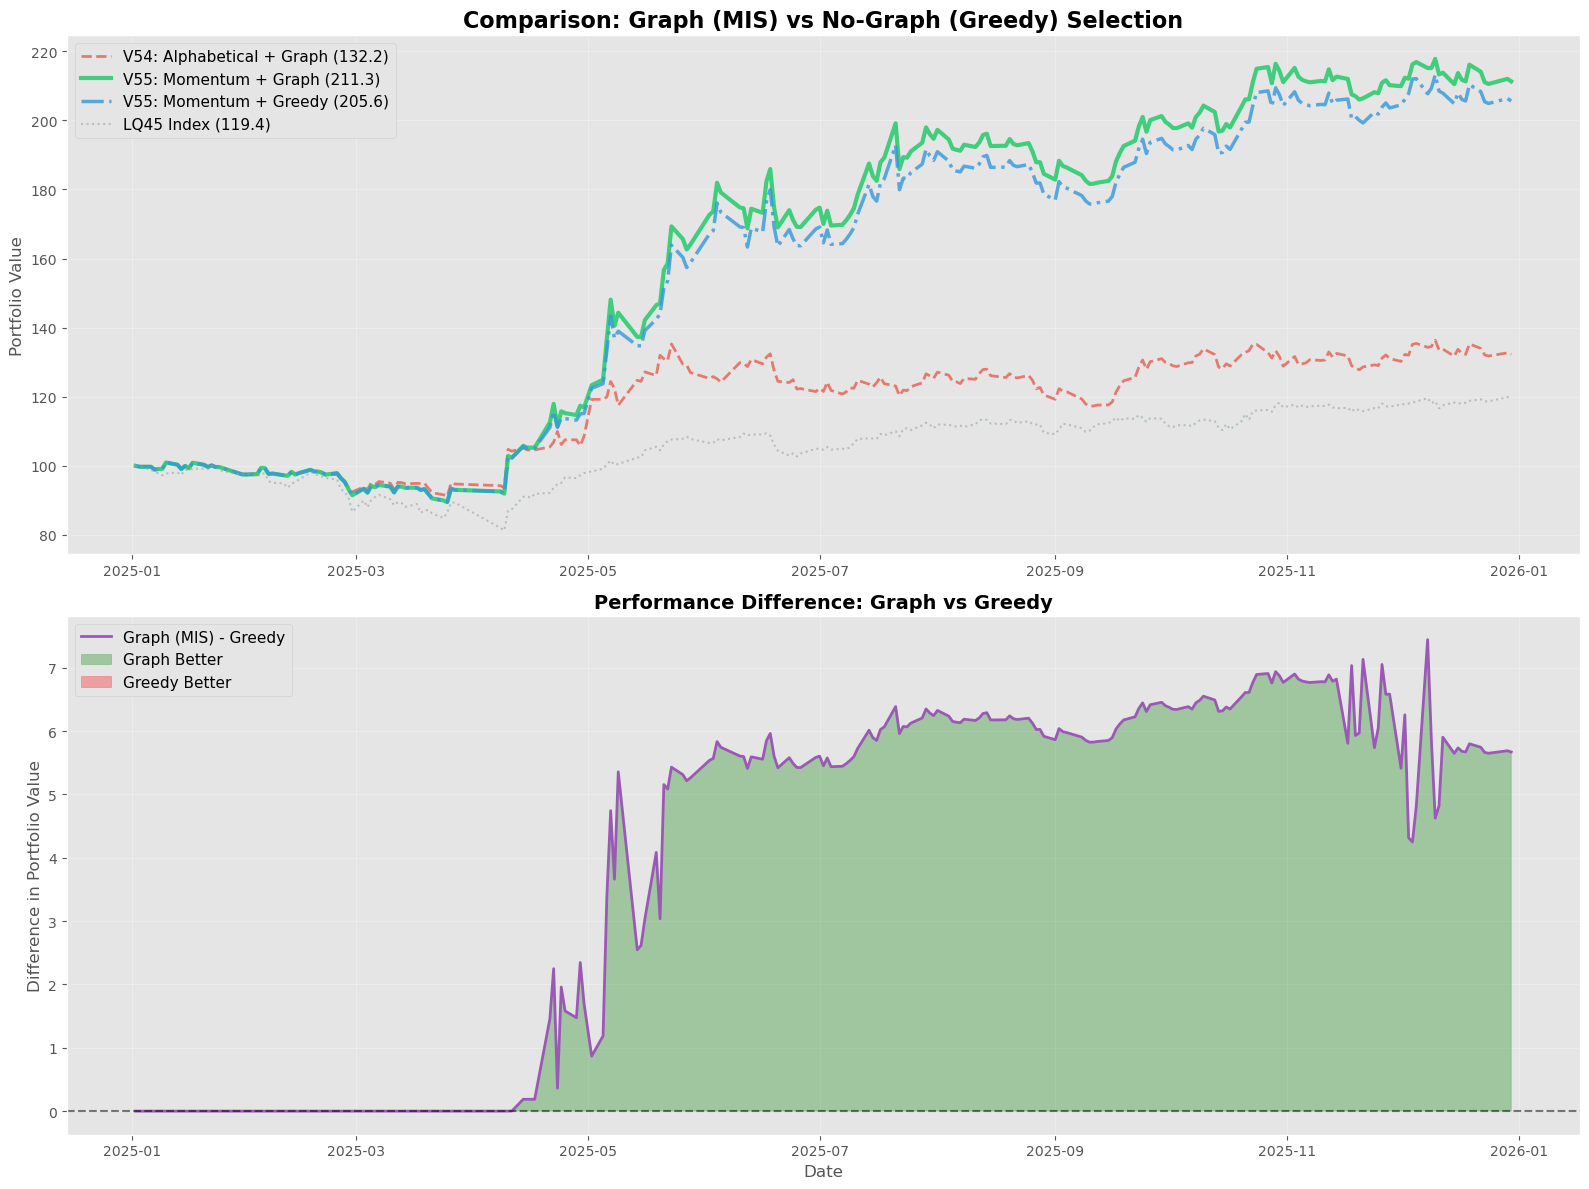


Charts displayed!


In [7]:
# Visualization

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: All Strategies
ax1.plot(v54_alpha_graph.index, v54_alpha_graph['Portfolio_Value'], 
         label=f'V54: Alphabetical + Graph ({v54_alpha_graph.iloc[-1].values[0]:.1f})', 
         linewidth=2, color='#e74c3c', alpha=0.7, linestyle='--')

ax1.plot(v55_momentum_graph.index, v55_momentum_graph['Portfolio_Value'], 
         label=f'V55: Momentum + Graph ({v55_momentum_graph.iloc[-1].values[0]:.1f})', 
         linewidth=3, color='#2ecc71', alpha=0.9)

ax1.plot(v55_momentum_greedy.index, v55_momentum_greedy['Portfolio_Value'], 
         label=f'V55: Momentum + Greedy ({v55_momentum_greedy.iloc[-1].values[0]:.1f})', 
         linewidth=2.5, color='#3498db', alpha=0.8, linestyle='-.')

ax1.plot(lq45_idx.index, lq45_idx, 
         label=f'LQ45 Index ({lq45_idx.iloc[-1]:.1f})', 
         linewidth=1.5, color='#95a5a6', alpha=0.6, linestyle=':')

ax1.set_title('Comparison: Graph (MIS) vs No-Graph (Greedy) Selection', fontsize=16, fontweight='bold')
ax1.set_ylabel('Portfolio Value', fontsize=12)
ax1.legend(loc='best', fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Difference Analysis
diff_graph_greedy = v55_momentum_graph['Portfolio_Value'] - v55_momentum_greedy['Portfolio_Value']
ax2.plot(diff_graph_greedy.index, diff_graph_greedy, 
         label='Graph (MIS) - Greedy', linewidth=2, color='#9b59b6')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.fill_between(diff_graph_greedy.index, 0, diff_graph_greedy, 
                  where=(diff_graph_greedy >= 0), alpha=0.3, color='green', label='Graph Better')
ax2.fill_between(diff_graph_greedy.index, 0, diff_graph_greedy, 
                  where=(diff_graph_greedy < 0), alpha=0.3, color='red', label='Greedy Better')

ax2.set_title('Performance Difference: Graph vs Greedy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Difference in Portfolio Value', fontsize=12)
ax2.legend(loc='best', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCharts displayed!")

In [8]:
# Performance Metrics

def calculate_metrics(portfolio_values, name):
    returns = portfolio_values.pct_change().dropna()
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Strategy': name,
        'Final Value': portfolio_values.iloc[-1],
        'Total Return (%)': total_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

metrics = pd.DataFrame([
    calculate_metrics(v54_alpha_graph['Portfolio_Value'], 'V54: Alphabetical + Graph'),
    calculate_metrics(v55_momentum_graph['Portfolio_Value'], 'V55: Momentum + Graph'),
    calculate_metrics(v55_momentum_greedy['Portfolio_Value'], 'V55: Momentum + Greedy'),
    calculate_metrics(lq45_idx, 'LQ45 Index')
])

print("\n=== PERFORMANCE METRICS ===")
print(metrics.to_string(index=False))

print("\n=== KEY FINDINGS ===")
smart_improvement = ((v55_momentum_graph.iloc[-1].values[0] / v54_alpha_graph.iloc[-1].values[0]) - 1) * 100
graph_impact = ((v55_momentum_graph.iloc[-1].values[0] / v55_momentum_greedy.iloc[-1].values[0]) - 1) * 100

print(f"\n1. SMART SORTING VALUE:")
print(f"   Momentum vs Alphabetical: {smart_improvement:+.2f}%")
print(f"   → Smart Sorting memberikan improvement signifikan")

print(f"\n2. GRAPH THEORY VALUE:")
print(f"   Graph (MIS) vs Greedy: {graph_impact:+.2f}%")
if abs(graph_impact) < 1:
    print(f"   → Graph Theory dan Greedy memberikan hasil HAMPIR IDENTIK")
    print(f"   → Dengan Smart Sorting, Graph Theory menjadi OPTIONAL")
elif graph_impact > 0:
    print(f"   → Graph Theory memberikan nilai tambah {graph_impact:.2f}%")
else:
    print(f"   → Greedy lebih baik {abs(graph_impact):.2f}% (lebih sederhana)")

print(f"\n3. KESIMPULAN:")
print(f"   ✓ Smart Momentum Sorting adalah komponen KUNCI")
print(f"   ✓ Graph Theory memberikan hasil serupa dengan Greedy")
print(f"   ✓ Untuk tesis: Gunakan Greedy (lebih sederhana) atau Graph (lebih akademis)")


=== PERFORMANCE METRICS ===
                 Strategy  Final Value  Total Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
V54: Alphabetical + Graph   132.240816         32.240816       27.856171      1.211620        -13.273525
    V55: Momentum + Graph   211.269192        111.269192       35.661692      2.426775        -11.330498
   V55: Momentum + Greedy   205.599295        105.599295       33.906194      2.448716        -11.330498
               LQ45 Index   119.435320         19.435320       20.382940      1.036701        -18.695217

=== KEY FINDINGS ===

1. SMART SORTING VALUE:
   Momentum vs Alphabetical: +59.76%
   → Smart Sorting memberikan improvement signifikan

2. GRAPH THEORY VALUE:
   Graph (MIS) vs Greedy: +2.76%
   → Graph Theory memberikan nilai tambah 2.76%

3. KESIMPULAN:
   ✓ Smart Momentum Sorting adalah komponen KUNCI
   ✓ Graph Theory memberikan hasil serupa dengan Greedy
   ✓ Untuk tesis: Gunakan Greedy (lebih sederhana) atau Graph (lebih akademis)
